## Step 1: Data Cleaning


### 1.1 Dataset Loading and Structural Inspection



In [46]:
import numpy as np
import pandas as pd

# Load the dataset
df = pd.read_csv("house_prices.csv")

# Display basic structural information
print(f"Dataset Shape: {df.shape}")
print("\n--- Data Types and Non-Null Counts ---")
print(df.info())

# Display initial missing value counts
print("\n--- Missing Values Count ---")
print(df.isnull().sum()[df.isnull().sum() > 0])

Dataset Shape: (9808, 18)

--- Data Types and Non-Null Counts ---
<class 'pandas.DataFrame'>
RangeIndex: 9808 entries, 0 to 9807
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   url               9808 non-null   str    
 1   price             9808 non-null   int64  
 2   city              9766 non-null   str    
 3   district          9766 non-null   str    
 4   bedrooms          8854 non-null   float64
 5   bathrooms         9149 non-null   float64
 6   area_sqft         9539 non-null   float64
 7   land_perches      5158 non-null   float64
 8   property_type     9808 non-null   str    
 9   furnished         5837 non-null   str    
 10  has_pool          9808 non-null   bool   
 11  has_garden        9808 non-null   bool   
 12  has_cctv          9808 non-null   bool   
 13  has_hot_water     9808 non-null   bool   
 14  has_servant_room  9808 non-null   bool   
 15  has_balcony       9808 non-null   

### 1.2 Feature Dropping



In [47]:
# Remove the unique identifier column
df = df.drop(columns=["url"])
print(f"Columns remaining: {df.columns.tolist()}")

Columns remaining: ['price', 'city', 'district', 'bedrooms', 'bathrooms', 'area_sqft', 'land_perches', 'property_type', 'furnished', 'has_pool', 'has_garden', 'has_cctv', 'has_hot_water', 'has_servant_room', 'has_balcony', 'has_garage', 'Price_Category']


### 1.3 Handling Invalid Structural Values (Zeros)



In [48]:
# Convert logical 0 values in spatial features to NaN
invalid_area_zeros = (df["area_sqft"] == 0).sum()
invalid_land_zeros = (df["land_perches"] == 0).sum()

print(f"Invalid 0 entries found in area_sqft: {invalid_area_zeros}")
print(f"Invalid 0 entries found in land_perches: {invalid_land_zeros}")

df["area_sqft"] = df["area_sqft"].replace(0, np.nan)
df["land_perches"] = df["land_perches"].replace(0, np.nan)

Invalid 0 entries found in area_sqft: 16
Invalid 0 entries found in land_perches: 1


### 1.4 Handling Missing Categorical Features



In [49]:
# Address missing values in categorical text columns
df["city"] = df["city"].fillna("Unknown")
df["district"] = df["district"].fillna("Unknown")
df["furnished"] = df["furnished"].fillna("Not Specified")

# Verify categorical columns are clean
print("Remaining missing categorical values:")
print(df[["city", "district", "furnished"]].isnull().sum())

Remaining missing categorical values:
city         0
district     0
furnished    0
dtype: int64


## Step 2: Data Preprocessing


### 2.1 Converting Booleans to Binary Numeric Features


In [50]:
# List of structural boolean features
boolean_features = [
    "has_pool", "has_garden", "has_cctv", "has_hot_water", 
    "has_servant_room", "has_balcony", "has_garage"
]

# Map Boolean states to discrete binary integers (0 or 1)
for col in boolean_features:
    df[col] = df[col].astype(int)

# Confirm datatype casting
print(df[boolean_features].dtypes)

has_pool            int64
has_garden          int64
has_cctv            int64
has_hot_water       int64
has_servant_room    int64
has_balcony         int64
has_garage          int64
dtype: object


### 2.2 Target Isolation & Log-Transformation



In [51]:
# Separate the design matrix (X) from the target vector (y)
X = df.drop(columns=["price"])

# Apply log1p transformation to handle potential structural zeros or extreme skewness
y = np.log1p(df["price"])

print(f"Feature Space Dimensions: {X.shape}")
print(f"Transformed Target Vector Shape: {y.shape}")

Feature Space Dimensions: (9808, 16)
Transformed Target Vector Shape: (9808,)


### 2.3 Train-Test Data Splitting


In [52]:
from sklearn.model_selection import train_test_split

# Split dataset into training (80%) and testing validation (20%) matrices
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training Features: {X_train.shape} | Test Features: {X_test.shape}")

Training Features: (7846, 16) | Test Features: (1962, 16)


### 2.4 Constructing the Automated Preprocessing Pipeline



In [53]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Define specific column groups
numerical_features = ["bedrooms", "bathrooms", "area_sqft", "land_perches"]
categorical_features = ["city", "district", "property_type", "furnished", "Price_Category"]

# 1. Numerical Engineering Pipeline: Median Imputation + Standardization Scaling
numerical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# 2. Categorical Engineering Pipeline: One-Hot Encoding with Out-Of-Sample Safety
categorical_pipeline = Pipeline([
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

# 3. Combined Pipeline Architecture
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numerical_pipeline, numerical_features),
        ("cat", categorical_pipeline, categorical_features)
    ],
    remainder="passthrough" # Passes through the pre-converted binary boolean features untouched
)

# Fit pipeline on training data and transform both partitions
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print(f"Processed Training Shape: {X_train_processed.shape}")
print(f"Processed Testing Shape: {X_test_processed.shape}")

Processed Training Shape: (7846, 131)
Processed Testing Shape: (1962, 131)


## Step 3: Exploratory Data Analysis (EDA)



In [54]:
import matplotlib.pyplot as plt
import seaborn as sns

# Reconstruct an un-skewed exploratory dataframe from the training split
eda_df = X_train.copy()
eda_df["price"] = np.expm1(y_train)  # Revert log1p transformation for authentic distribution analysis
eda_df["log_price"] = y_train

# Set global plotting style for professional presentation
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 10

### 3.1 Visualization 1: Target Variable Distribution (Raw vs. Log-Transformed)


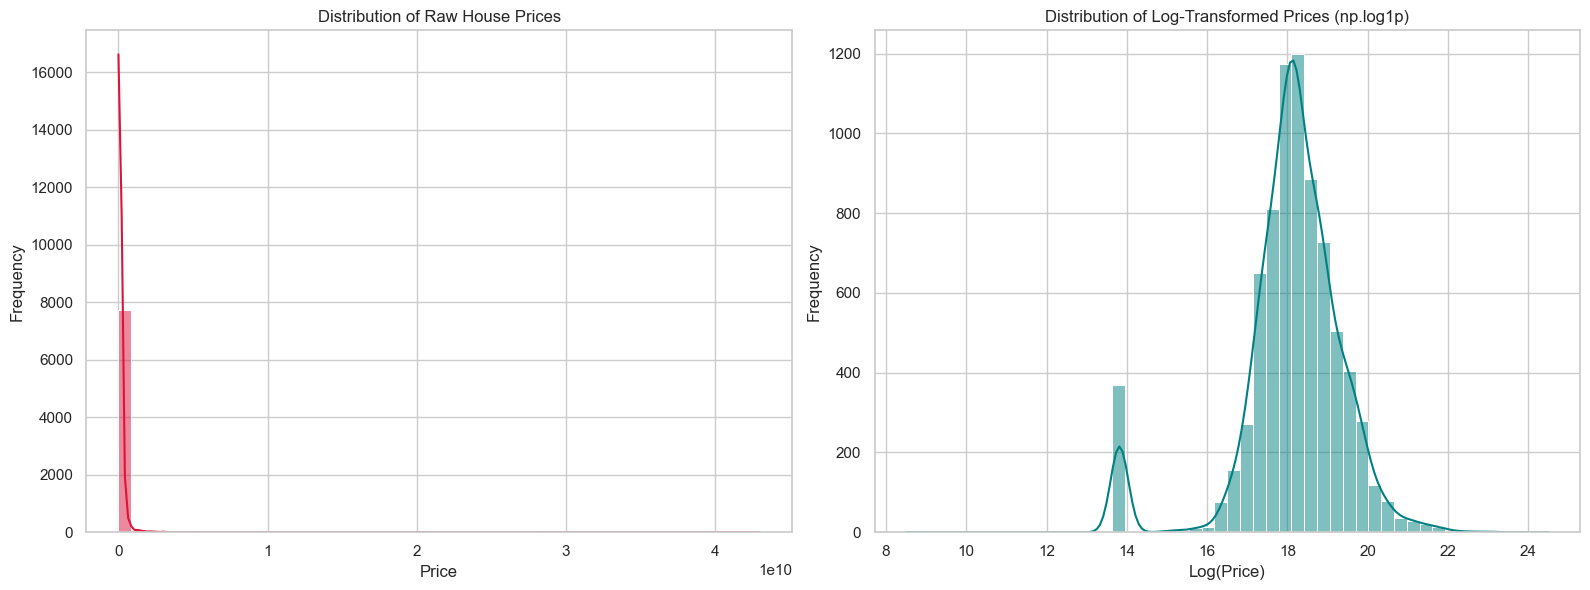

In [55]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: Raw Price Distribution
sns.histplot(eda_df["price"], bins=50, kde=True, color="crimson", ax=axes[0])
axes[0].set_title("Distribution of Raw House Prices")
axes[0].set_xlabel("Price")
axes[0].set_ylabel("Frequency")

# Right: Log-Transformed Price Distribution
sns.histplot(eda_df["log_price"], bins=50, kde=True, color="teal", ax=axes[1])
axes[1].set_title("Distribution of Log-Transformed Prices (np.log1p)")
axes[1].set_xlabel("Log(Price)")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

### 3.2 Visualization 2: Property Type vs. Log-Price Variance



C:\Users\S4JI_\AppData\Local\Temp\ipykernel_11144\1524137206.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="property_type", y="log_price", data=eda_df, palette="Set2")


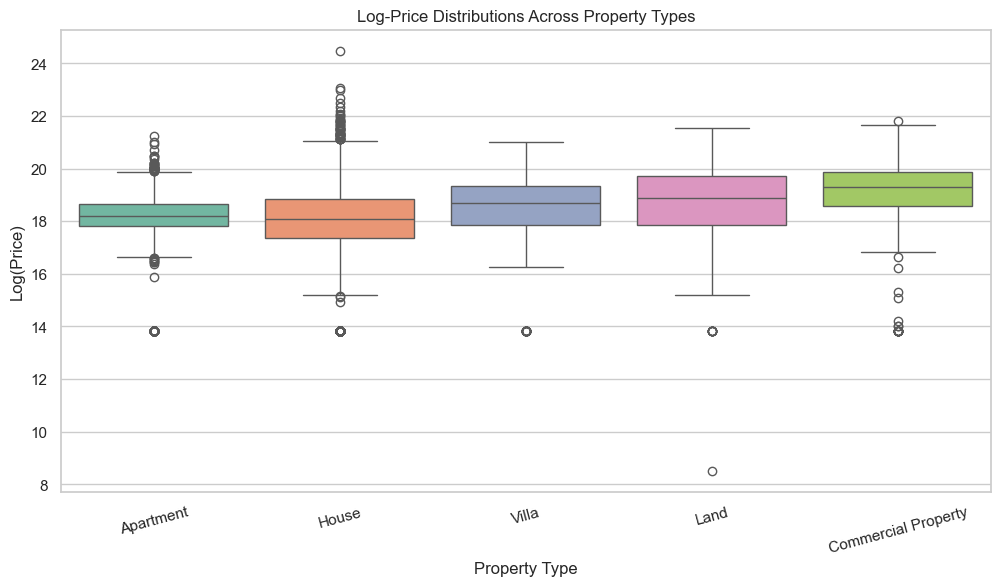

In [56]:
plt.figure(figsize=(12, 6))
sns.boxplot(x="property_type", y="log_price", data=eda_df, palette="Set2")
plt.title("Log-Price Distributions Across Property Types")
plt.xlabel("Property Type")
plt.ylabel("Log(Price)")
plt.xticks(rotation=15)
plt.show()

### 3.3 Visualization 3: Living Area Size vs. Log-Price



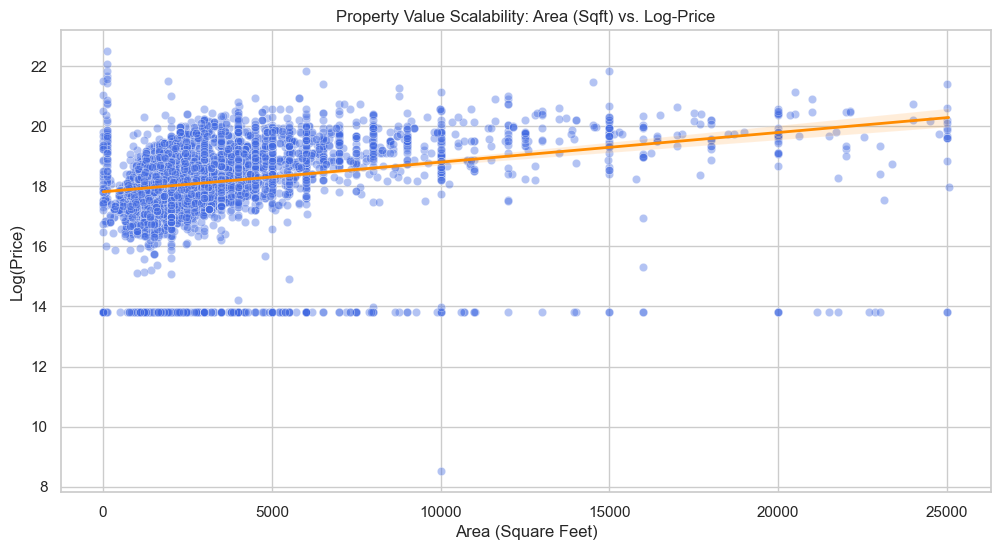

In [57]:
plt.figure(figsize=(12, 6))
# Filter extreme spatial outliers dynamically for clear visual representation
spatial_filter = eda_df["area_sqft"] < eda_df["area_sqft"].quantile(0.98)

sns.scatterplot(x="area_sqft", y="log_price", data=eda_df[spatial_filter], alpha=0.4, color="royalblue")
sns.regplot(x="area_sqft", y="log_price", data=eda_df[spatial_filter], scatter=False, color="darkorange", line_kws={"linewidth":2})

plt.title("Property Value Scalability: Area (Sqft) vs. Log-Price")
plt.xlabel("Area (Square Feet)")
plt.ylabel("Log(Price)")
plt.show()

### 3.4 Visualization 4: Correlation Matrix of Numeric & Feature Amenities



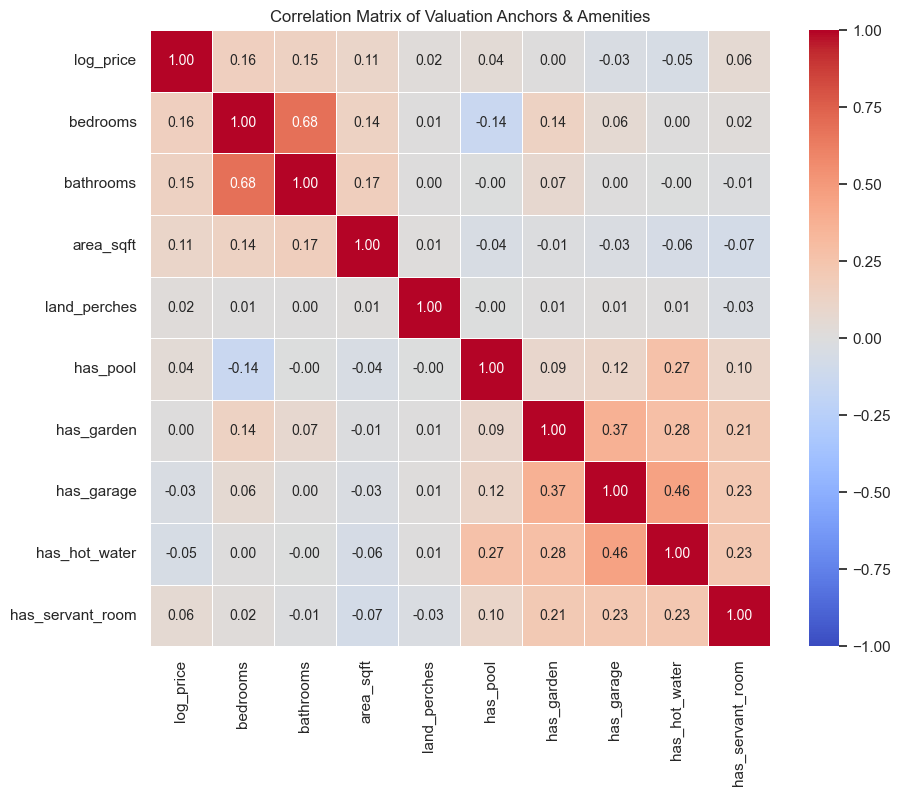

In [58]:
# Select key numerical and boolean indicators
corr_features = [
    "log_price", "bedrooms", "bathrooms", "area_sqft", "land_perches",
    "has_pool", "has_garden", "has_garage", "has_hot_water", "has_servant_room"
]

corr_matrix = eda_df[corr_features].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, linewidths=0.5)
plt.title("Correlation Matrix of Valuation Anchors & Amenities")
plt.show()

### 3.5 Visualization 5: Validation of Price Category Thresholds



C:\Users\S4JI_\AppData\Local\Temp\ipykernel_11144\2547666515.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x="Price_Category", y="log_price", data=eda_df, order=category_order, palette="viridis")


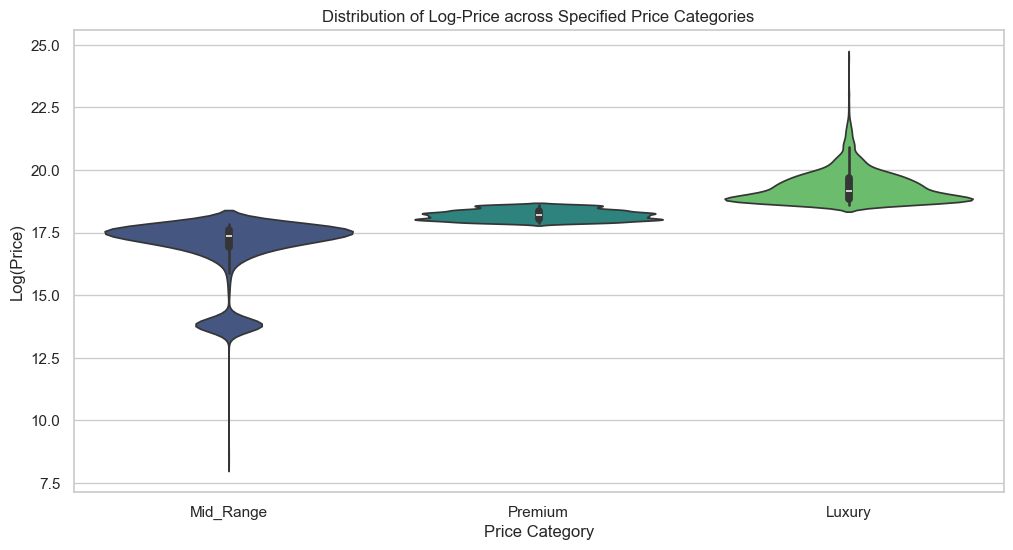

In [59]:
plt.figure(figsize=(12, 6))
category_order = eda_df.groupby("Price_Category")["log_price"].median().sort_values().index

sns.violinplot(x="Price_Category", y="log_price", data=eda_df, order=category_order, palette="viridis")
plt.title("Distribution of Log-Price across Specified Price Categories")
plt.xlabel("Price Category")
plt.ylabel("Log(Price)")
plt.show()

## Step 4: Hypothesis Testing

This step performs formal statistical inferences using our isolated target variable, **Log-Transformed Price (`log_price`)**, to validate if structural features and property classifications hold statistically significant relationships with market values.

In [60]:
import scipy.stats as stats

# Ensure data is referenced from the clean training split
test_df = X_train.copy()
test_df["log_price"] = y_train

### 4.1 Statistical Test 1: One-Way ANOVA (Analysis of Variance)

**Objective:** Determine if the mean log-price varies significantly across different property classifications (House, Apartment, Commercial Property, Villa, Land).

- **Target Variable:** `log_price` (Continuous)
- **Grouping Variable:** `property_type` (Categorical, 5 distinct groups)

#### Hypotheses Formulation

- **Null Hypothesis** ($H_0$): The true mean log-prices are equal across all property classifications:

$$ \mu_{\text{House}} = \mu_{\text{Apartment}} = \mu_{\text{Commercial}} = \mu_{\text{Villa}} = \mu_{\text{Land}} $$

- **Alternative Hypothesis** ($H_1$): At least one property type has a significantly different true mean log-price from the others.

In [61]:
# Extract target arrays for each group
property_groups = [group["log_price"].values for name, group in test_df.groupby("property_type")]

# Execute One-Way ANOVA
f_statistic, p_value_anova = stats.f_oneway(*property_groups)

print("--- One-Way ANOVA Results ---")
print(f"F-Statistic : {f_statistic:.4f}")
print(f"p-value     : {p_value_anova:.4e}")

--- One-Way ANOVA Results ---
F-Statistic : 38.3461
p-value     : 7.8822e-32


#### Statistical Interpretation

- **p-value:** $\approx 7.88 \times 10^{-32}$

- **Conclusion:** Because the p-value is substantially smaller than our significance threshold ($\alpha = 0.05$), we reject the Null Hypothesis ($H_0$). There is overwhelming statistical evidence that the mean log-price differs significantly based on the property type.

### 4.2 Statistical Test 2: Two-Sample Independent T-Test (Welch's T-Test)

**Objective:** Assess whether the presence of a premium luxury amenity, specifically a swimming pool (`has_pool`), structurally shifts the property's market value.

- **Target Variable:** `log_price` (Continuous)
- **Grouping Variable:** `has_pool` (Binary: 1 if present, 0 if absent)

#### Hypotheses Formulation

- **Null Hypothesis** ($H_0$): There is no difference in the true mean log-prices between properties with pools and properties without pools:

$$ \mu_{\text{Pool}} = \mu_{\text{No Pool}} $$

- **Alternative Hypothesis** ($H_1$): Properties with a swimming pool have a significantly different true mean log-price than properties without a pool:

$$ \mu_{\text{Pool}} \neq \mu_{\text{No Pool}} $$

In [62]:
# Isolate target distributions by binary flag state
pool_present = test_df[test_df["has_pool"] == 1]["log_price"]
pool_absent = test_df[test_df["has_pool"] == 0]["log_price"]

# Execute Welch's T-Test (does not assume equal population variances)
t_statistic, p_value_ttest = stats.ttest_ind(pool_present, pool_absent, equal_var=False)

print("--- Independent Two-Sample T-Test Results ---")
print(f"T-Statistic : {t_statistic:.4f}")
print(f"p-value     : {p_value_ttest:.4e}")

--- Independent Two-Sample T-Test Results ---
T-Statistic : 3.8622
p-value     : 1.1340e-04


#### Statistical Interpretation

- **p-value:** $\approx 1.13 \times 10^{-4}$

- **Conclusion:** Because the computed p-value is significantly below our alpha standard ($\alpha = 0.05$), we reject the Null Hypothesis ($H_0$). The data demonstrates that having a swimming pool yields a statistically significant difference in a property's final log-valuation.

## Step 5: Machine Learning Models


Performance is evaluated on both the **Log-Scale** (where the model minimizes errors) and the converted **Original Currency Scale** using Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and the Coefficient of Determination ($R^2$).

### 5.1 Model 1: Ridge Regression (Regularized Linear Baseline)



#### 5.1.1 Training and Evaluation

In [63]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1. Initialize and Fit Ridge Regression
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train_processed, y_train)

# 2. Predict on Log-Scale
y_pred_ridge_log = ridge_model.predict(X_test_processed)

# 3. Convert Back to Original Currency Scale
y_test_real = np.expm1(y_test)
y_pred_ridge_real = np.expm1(y_pred_ridge_log)

# 4. Calculate Diagnostics
ridge_r2_log = r2_score(y_test, y_pred_ridge_log)
ridge_mae_real = mean_absolute_error(y_test_real, y_pred_ridge_real)

print(f"Ridge Log-Scale R² Score : {ridge_r2_log:.4f}")
print(f"Ridge Real-Scale MAE     : {ridge_mae_real:,.2f}")

Ridge Log-Scale R² Score : 0.5980
Ridge Real-Scale MAE     : 80,752,238.43


#### 5.1.2 Visualization (Predicted vs. Actual)

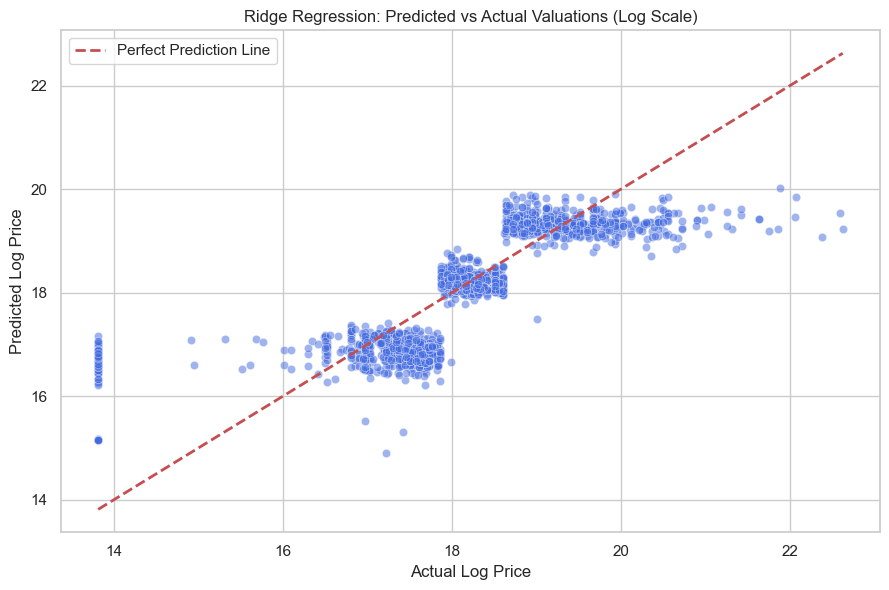

In [64]:
plt.figure(figsize=(9, 6))
sns.scatterplot(x=y_test, y=y_pred_ridge_log, alpha=0.5, color="royalblue")

# Plot perfect prediction diagonal baseline reference
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--", lw=2, label="Perfect Prediction Line")

plt.title("Ridge Regression: Predicted vs Actual Valuations (Log Scale)", fontsize=12)
plt.xlabel("Actual Log Price")
plt.ylabel("Predicted Log Price")
plt.legend()
plt.tight_layout()
plt.show()

### 5.2 Model 2: Random Forest Regressor (Non-Linear Ensemble)


#### 5.2.1 Training and Evaluation

In [65]:
from sklearn.ensemble import RandomForestRegressor

# 1. Initialize and Fit Random Forest (leveraging all available CPU cores via n_jobs=-1)
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train_processed, y_train)

# 2. Predict on Log-Scale
y_pred_rf_log = rf_model.predict(X_test_processed)

# 3. Convert Back to Original Currency Scale
y_pred_rf_real = np.expm1(y_pred_rf_log)

# 4. Calculate Diagnostics
rf_r2_log = r2_score(y_test, y_pred_rf_log)
rf_mae_real = mean_absolute_error(y_test_real, y_pred_rf_real)

print(f"Random Forest Log-Scale R² Score : {rf_r2_log:.4f}")
print(f"Random Forest Real-Scale MAE     : {rf_mae_real:,.2f}")

Random Forest Log-Scale R² Score : 0.7788
Random Forest Real-Scale MAE     : 54,709,906.78


#### 5.2.2 Visualization (Predicted vs. Actual)

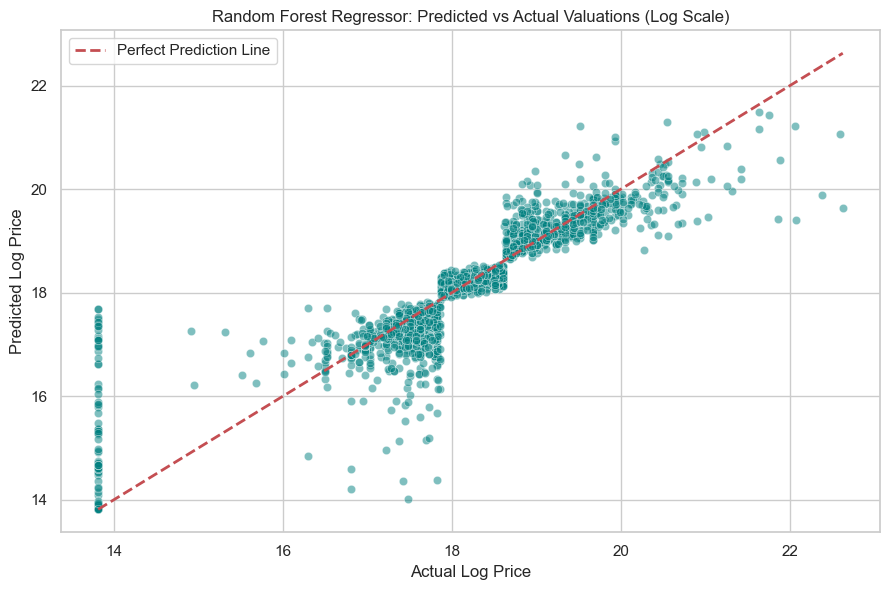

In [66]:
plt.figure(figsize=(9, 6))
sns.scatterplot(x=y_test, y=y_pred_rf_log, alpha=0.5, color="teal")

# Plot perfect prediction diagonal baseline reference
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--", lw=2, label="Perfect Prediction Line")

plt.title("Random Forest Regressor: Predicted vs Actual Valuations (Log Scale)", fontsize=12)
plt.xlabel("Actual Log Price")
plt.ylabel("Predicted Log Price")
plt.legend()
plt.tight_layout()
plt.show()

## Predictive Modeling Performance Synthesis

Two distinct model architectures were evaluated on the test partition. The final results are summarized below:

| Performance Metric                          | Ridge Regression Baseline | Random Forest Regressor |
|---------------------------------------------|---------------------------|--------------------------|
| Log-Scale $R^2$ Score                       | 0.5980                    | 0.7790                   |
| Real-Scale $R^2$ Score                      | 0.1422                    | 0.3768                   |
| Real-Scale Mean Absolute Error (MAE)        | 80,752,238.43             | 54,704,921.59            |
| Model Type                                  | Linear Regularized ($L_2$) | Non-Linear Ensemble (Bagging) |

